# 04 — Fokker-Planck : le paysage de l'opinion publique

On passe des individus à la **densité de probabilité** $P(x, t)$ de l'opinion
macroscopique :

$$\frac{\partial P}{\partial t}
  = -\frac{\partial}{\partial x}\big[A(x) P\big]
    + \frac{\partial^2}{\partial x^2}\big[B(x) P\big]$$

Ce notebook porte les deux corrections les plus importantes de l'audit
(points 1 et 3), et il vaut la peine de les énoncer avant de calculer.

**La dérive du fil, $A(x) = Jx + H$, ne peut pas produire de transition de phase.**
Elle dérive du potentiel $V(x) = -\frac{J}{2}x^2 - Hx$, dont l'exponentielle est
convexe : la distribution serait maximale aux extrêmes *à toute température*. Le
terme manquant est l'**entropie de mélange**, c'est-à-dire le nombre de
configurations individuelles compatibles avec une opinion moyenne $x$. En l'ajoutant
on retrouve exactement l'énergie libre $F = E - TS$ que le fil invoquait :

$$f(x) = -\frac{J}{2}x^2 - Hx + T\left[\frac{1+x}{2}\ln\frac{1+x}{2} + \frac{1-x}{2}\ln\frac{1-x}{2}\right]$$

d'où $A(x) = -f'(x) = Jx + H - T\,\mathrm{artanh}(x)$, et une température critique de
champ moyen $T_c = J$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.fokker_planck import (
    FokkerPlanckSolver,
    diffusion_term,
    mean_field_free_energy,
    stationary_distribution,
)
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

grid = np.linspace(-0.98, 0.98, 601)
POPULATION = 400

## Le paysage d'énergie libre décide de tout

Trois régimes, lisibles directement sur la forme de $f(x)$ :

| Régime | Paysage | Société |
|---|---|---|
| $T > T_c$ | un seul puits, centré | débat fluide, modération majoritaire |
| $T < T_c$, $H = 0$ | deux puits symétriques | polarisation en deux blocs égaux |
| $T < T_c$, $H > 0$ | deux puits inclinés | faux consensus imposé par le champ |

In [2]:
scenarios = {
    "fluide  ($T=2.0$, $H=0$)": dict(temperature=2.0, field=0.0, colour=PALETTE["remedy"]),
    "polarisée  ($T=0.7$, $H=0$)": dict(temperature=0.7, field=0.0, colour=PALETTE["order"]),
    "manipulée  ($T=0.7$, $H=0.1$)": dict(temperature=0.7, field=0.1, colour=PALETTE["field"]),
}

for label, setup in scenarios.items():
    density = stationary_distribution(
        grid, field=setup["field"], temperature=setup["temperature"], population=POPULATION
    )
    mean_opinion = float(np.trapezoid(grid * density, grid))
    moderate = float(density[len(grid) // 2])
    print(f"{label:30s} opinion moyenne = {mean_opinion:+.3f}   densité de modérés = {moderate:.2e}")

fluide  ($T=2.0$, $H=0$)       opinion moyenne = -0.000   densité de modérés = 5.66e+00
polarisée  ($T=0.7$, $H=0$)    opinion moyenne = -0.000   densité de modérés = 1.35e-15
manipulée  ($T=0.7$, $H=0.1$)  opinion moyenne = +0.883   densité de modérés = 1.57e-36


## La diffusion en $1/N$ : ce qu'une grande population fait réellement

Le terme de diffusion retenu est $B(x) = T(1-x^2)/N$. Il dit quelque chose de
**contraire au récit initial** : plus la population est grande, plus le bruit de sa
variable macroscopique est faible. C'est la loi des grands nombres.

Il n'y a pas de contradiction, mais deux échelles qu'il faut cesser de confondre :

* l'entropie de configuration **totale** est extensive et croît avec $N$ ;
* les fluctuations de la **moyenne** $x$ décroissent en $1/N$.

La thèse défendable est donc : *une grande population ne devient pas bruyante, elle
devient rigide.* Et c'est cette rigidité qui rend la polarisation irréversible — un
système sans plasticité stochastique ne peut plus quitter le puits où il est tombé.

In [3]:
for population in (50, 400, 5_000):
    print(
        f"N = {population:6d} : B(0) = {float(diffusion_term(0.0, population=population)):.2e}"
        f"   densité de modérés = {stationary_distribution(grid, temperature=0.7, population=population)[len(grid) // 2]:.2e}"
    )

N =     50 : B(0) = 2.00e-02   densité de modérés = 1.96e-02
N =    400 : B(0) = 2.50e-03   densité de modérés = 1.35e-15
N =   5000 : B(0) = 2.00e-04   densité de modérés = 2.53e-194


## Évolution temporelle : la scission en direct

On part d'une société modérée — une gaussienne centrée sur $x = 0$ — et on laisse
l'équation agir. Sous $T_c$, la distribution se creuse au centre et se scinde. Le
solveur est en volumes finis à flux nul aux bords : la masse de probabilité est
conservée **exactement**, ce qui permet de distinguer un vrai effondrement de la
modération d'une fuite numérique.

In [4]:
solver = FokkerPlanckSolver(points=601, temperature=0.7, population=POPULATION)
solution = solver.solve(total_time=80.0, snapshots=5)

print(f"dérive de masse sur toute l'intégration : {solution.mass_drift:.2e}")
print(f"modes finaux : {np.round(solution.modes, 3)}")

dérive de masse sur toute l'intégration : 3.77e-15
modes finaux : [-0.832  0.832]


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_130/2627606867.py:11: SyntaxWarning: invalid escape sequence '\m'
  landscape.set_ylabel("énergie libre $f(x) - f_{\min}$")


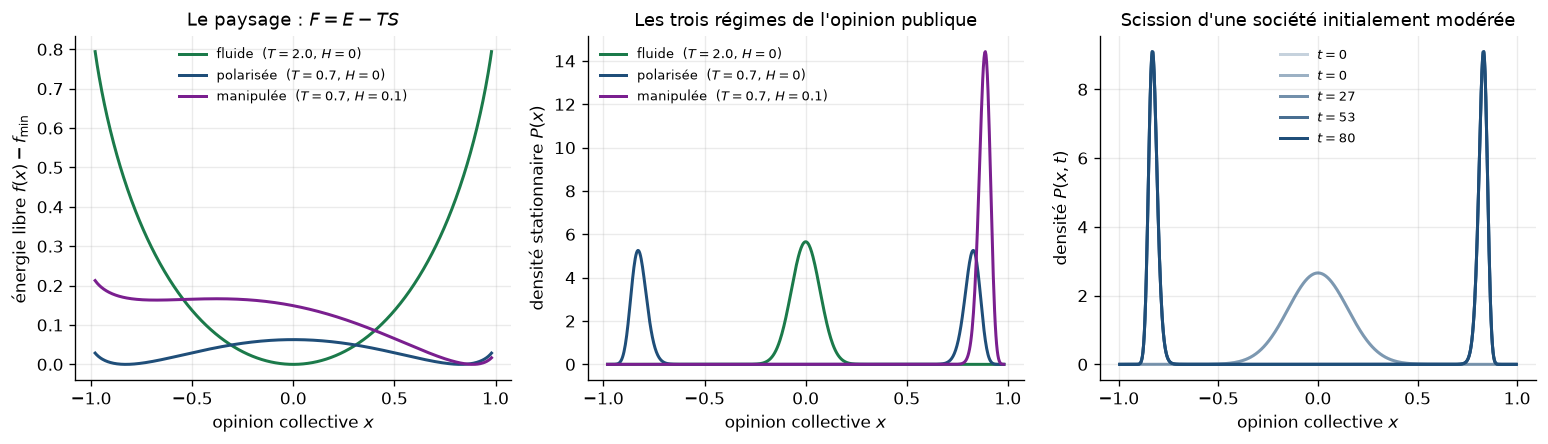

In [5]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.8))
landscape, stationary, evolution = axes

for label, setup in scenarios.items():
    energies = mean_field_free_energy(
        grid, field=setup["field"], temperature=setup["temperature"]
    )
    landscape.plot(grid, energies - energies.min(), color=setup["colour"], label=label)

landscape.set_xlabel("opinion collective $x$")
landscape.set_ylabel("énergie libre $f(x) - f_{\min}$")
landscape.set_title("Le paysage : $F = E - TS$")
landscape.legend(fontsize=8)

for label, setup in scenarios.items():
    density = stationary_distribution(
        grid, field=setup["field"], temperature=setup["temperature"], population=POPULATION
    )
    stationary.plot(grid, density, color=setup["colour"], label=label)

stationary.set_xlabel("opinion collective $x$")
stationary.set_ylabel("densité stationnaire $P(x)$")
stationary.set_title("Les trois régimes de l'opinion publique")
stationary.legend(fontsize=8)

shades = np.linspace(0.25, 1.0, len(solution.times))
for snapshot, time, shade in zip(solution.history, solution.times, shades):
    evolution.plot(solver.grid, snapshot, color=PALETTE["order"], alpha=shade,
                   label=f"$t = {time:.0f}$")

evolution.set_xlabel("opinion collective $x$")
evolution.set_ylabel("densité $P(x, t)$")
evolution.set_title("Scission d'une société initialement modérée")
evolution.legend(fontsize=8)

save_figure(figure, "fig04_paysage.png")
plt.show()

## Ce que le notebook établit

1. Avec l'entropie de mélange rétablie, le modèle possède une **vraie transition de
   phase** à $T_c = J$ — ce que la formulation initiale ne pouvait pas produire.
2. Les trois scénarios de la note (fluide, polarisé, manipulé) apparaissent comme
   trois formes du même paysage d'énergie libre, obtenues en changeant deux
   paramètres. Le « faux consensus » n'est pas une hypothèse ad hoc : c'est le puits
   incliné.
3. La densité de modérés s'effondre exponentiellement avec $N$ : dans une grande
   population sous $T_c$, la modération n'est pas minoritaire, elle est
   **statistiquement inaccessible**.
4. La masse de probabilité est conservée à la précision machine : les conclusions ne
   sont pas un artefact du schéma numérique.